Empirically find the time complexity of capytaine-solving operations. The dominating component is a quadratic dependence on panel count in solving the radiation problem.

In [1]:
# Imports
import sys
from pathlib import Path
HERE = Path.cwd().resolve()

dir_path_str = str((HERE / "..").resolve())
if dir_path_str not in sys.path:
  sys.path.insert(0, dir_path_str)
store_file = str((HERE / "data" / "cpt-timing.pkl").resolve())

from capytaine_generator import CapytaineSlantSolver

import pickle
import numpy as np
import time
import capytaine as cpt

import matplotlib.pyplot as plt

In [2]:
class TimedCapytaineSolver(CapytaineSlantSolver):
    def construct_and_solve(self, a, d_in, d_out, heaving, t_densities, f_densities, h, omega, rho):
        t1 = time.perf_counter()
        pt_lst = self.get_points(a, d_in, d_out)
        body, panel_count, mask = self._CapytaineSlantSolver__make_body(pt_lst, t_densities, f_densities, heaving)
        body.dofs["Heave"] = mask  
        t2 = time.perf_counter()
        
        rad_problem = cpt.RadiationProblem(body = body, omega = omega, water_depth = h, rho = rho)
        t3 = time.perf_counter()
        result_r, t_diff = self._CapytaineSlantSolver__timed_solve(rad_problem, 1)
        t4 = time.perf_counter()

        diff_problem = cpt.DiffractionProblem(body = body, omega = omega, water_depth = h, rho = rho)
        t5 = time.perf_counter()
        result_d, t_diff_d = self._CapytaineSlantSolver__timed_solve(diff_problem, 1)
        t6 = time.perf_counter()

        results = {"am result" : result_r.added_mass["Heave"],
                    "dp result" : result_r.radiation_damping["Heave"],
                    "Panel Count" : panel_count,
                    "Heave Panel Count" : mask.count([0, 0, 1])}
    
        time_results = {"geometry setup" : t2 - t1,
                    "radiation problem setup" : t3 - t2,
                    "radiation problem solve" : t4 - t3,
                    "diffraction problem setup" : t5 - t4,
                    "diffraction problem solve" : t6 - t5}

        return results, time_results

In [3]:
# Geometry variables
base_a = [3, 10]
base_d = [35, 3]
base_h = 70
base_omega = 0.1
rho = 1023

densities = np.linspace(0.1, 5, 50)

labels = ["geometry setup", "radiation problem setup", "radiation problem solve", "diffraction problem setup", "diffraction problem solve"]
heaves = [[1, 1], [0, 1], [1, 0]]

def random_multiplier():
  return np.random.uniform(low = 0.7, high = 1.3)

def randomized_dimensions():
  vals = [val * random_multiplier() for val in [base_a[0], base_a[1], base_d[0], base_d[1], base_h, base_omega]]
  return [vals[0], vals[1]], [vals[2], vals[3]], vals[4], vals[5]

def generate_area_densities(d, a, inner_density, outer_density):
  # density = panels/(m^2), divs = m/panel
  idiv = np.sqrt(1/inner_density)
  odiv = np.sqrt(1/outer_density)
  t_densities = [max(int((2 * np.pi * a[0] / idiv)) + 1, 4),
                 max(int((2 * np.pi * a[1] / odiv)) + 1, 4)]
  f_densities = [int(a[0]/idiv) + 1,
                 int((d[0] - d[1])/idiv) + 1,
                 int((a[1] - a[0])/odiv) + 1,
                 int(d[1]/odiv) + 1]
  return t_densities, f_densities

In [4]:
# Timing is assumed to be independent of geometry (at finite depth), and only dependent on the number of panels.
result_data = [[], [], []]
time_data = [{label:[] for label in labels}, {label:[] for label in labels}, {label:[] for label in labels}]

# initial run for compilation
solver = TimedCapytaineSolver(False, False, False, False, False)
t_densities, f_densities = generate_area_densities(base_d, base_a, 1, 1)
_ = solver.construct_and_solve(base_a, base_d, base_d, heaves[0], t_densities, f_densities, base_h, base_omega, rho)

for area_density in densities: # Generate data for varying panel counts, dimensions, heaves
  for i in range(3):
    heaving = heaves[i]
    a, d, h, m0 = randomized_dimensions()
    t_densities, f_densities = generate_area_densities(d, a, area_density, area_density)
    results, time_results = solver.construct_and_solve(a, d, d, heaving, t_densities, f_densities, h, m0, rho)
    result_data[i].append(results)
    for label in labels:
      time_data[i][label].append(time_results[label])

for i in range(3):
  time_data[i]["Panel Counts"] = [entry["Panel Count"] for entry in result_data[i]]
  time_data[i]["Heave Panel Counts"] = [entry["Heave Panel Count"] for entry in result_data[i]]
combined_data = {key : time_data[0][key] + time_data[1][key] + time_data[2][key] for key in list(time_data[0].keys())}

with open(store_file, "wb") as f:
  pickle.dump(combined_data, f)

with open(store_file, 'rb') as f:
  combined_data = pickle.load(f)

In [5]:
def plot_dependence(data, key, modifier, xlab):
  xs = [modifier(data["Panel Counts"][i], data["Heave Panel Counts"][i]) for i in range(len(data["Panel Counts"]))]
  ys = data[key]
  coeffs = np.polyfit(xs, ys, deg=1)
  fit_fn = np.poly1d(coeffs)
  x_line = np.linspace(min(xs), max(xs), 100)
  slope, intercept = coeffs
  equation = f"y = {slope:.2e}x + {intercept:.2e}"
  plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
          fontsize=12, verticalalignment='top', color='red')
  plt.plot(x_line, fit_fn(x_line), color="red", label="Best-fit line")
  plt.scatter(xs, ys, color = "blue", s=10)
  plt.xlabel(xlab)
  plt.ylabel("Time")
  plt.legend()
  plt.title(key + " computation")
  plt.show()
  return slope

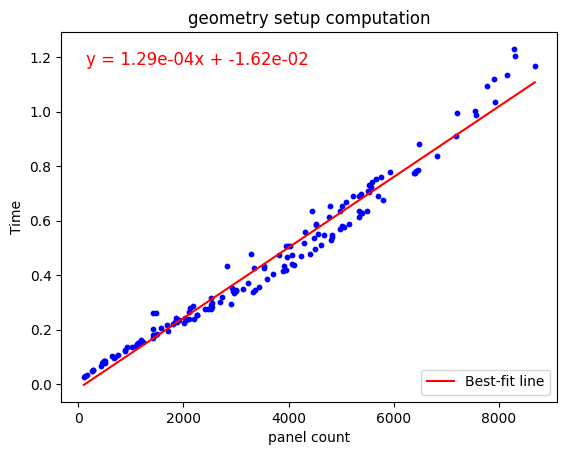

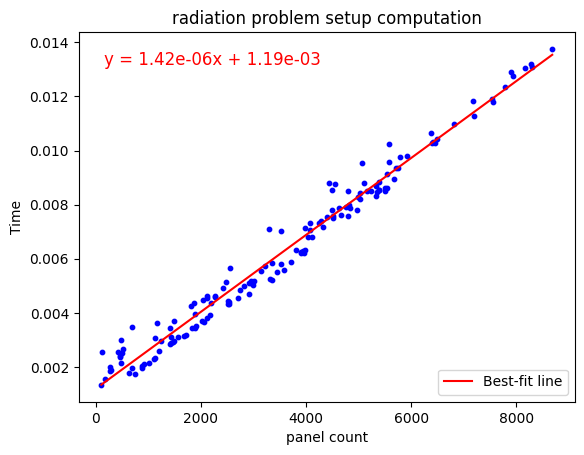

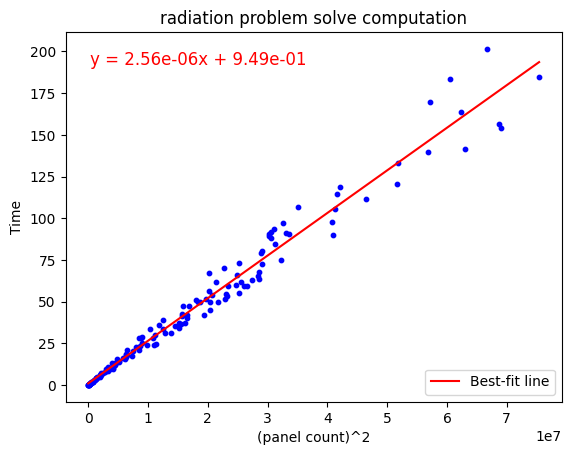

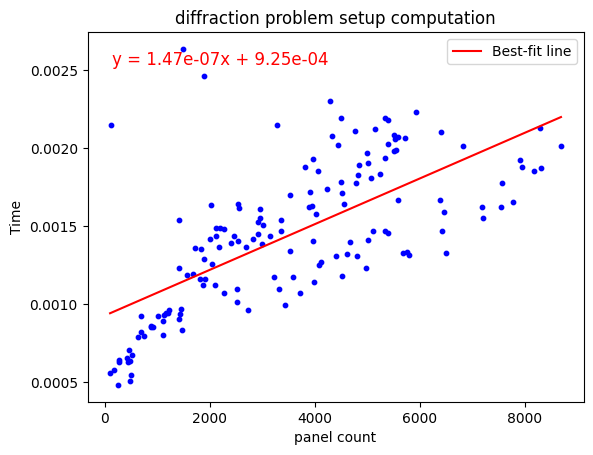

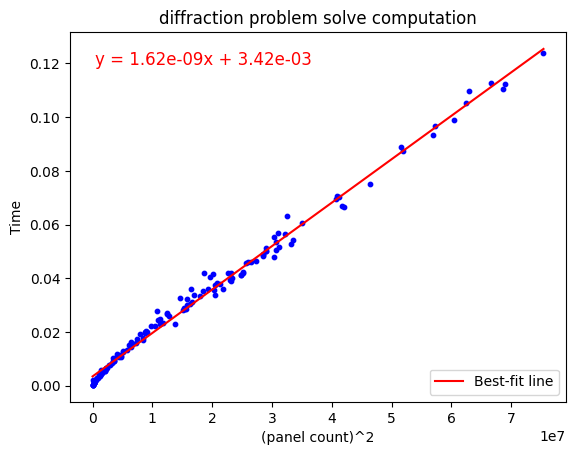

In [6]:
fit_data = {labels[0] : [lambda x, y : x, "panel count"],
            labels[1] : [lambda x, y : x, "panel count"],
            labels[2] : [lambda x, y : x**2, "(panel count)^2"],
            labels[3] : [lambda x, y : x, "panel count"],
            labels[4] : [lambda x, y : x**2, "(panel count)^2"]}

for label in labels:
  fit_data[label].append(plot_dependence(combined_data, label, fit_data[label][0], fit_data[label][1]))

In [7]:
# Extrapolate computation time:
def cpt_computation_time(panel_count):
  times = [fit_data[label][0](panel_count, None) * fit_data[label][2] for label in labels]
  return sum(times)